# 7-1 똑똑한 어휘 사전, 임베딩

본 노트북은 7-1 절 본문의 [코드 7-1] 예제와, 본문이 "깃허브 노트북에서 제공" 으로 안내한 GloVe 임베딩 데이터 로딩 코드, 그리고 [그림 7-6] 의 가족 관계 단어 시각화를 포함한다.

다루는 내용
- GloVe 6B 100d 데이터 다운로드 위치 안내와 로딩
- `[코드 7-1]` 단어 boy 의 임베딩 벡터 확인
- 가족 관계 단어 8 개의 임베딩 벡터를 PCA 로 2 차원에 시각화

> GloVe 임베딩 파일은 외부에서 내려받는 대형 데이터이므로 깃허브 저장소 규약(§13.9)에 따라 `'../../download/glove.6B.100d.txt'` 로 읽는다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, numpy, matplotlib 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q matplotlib numpy torch

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# # 참고 - 라이브러리 import 와 시드 고정
# import random

# import matplotlib.pyplot as plt
# import numpy as np
# import torch

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# device = common.get_device()

## 참고 - GloVe 임베딩 데이터 다운로드와 로딩

본문에 따라 GloVe 공식 홈페이지(https://nlp.stanford.edu/projects/glove/) 에서 `glove.6B.zip` 을 내려받고 그 안의 `glove.6B.100d.txt` 파일을 사용한다.

- 학습 말뭉치: 60억 단어 (6B token)
- 어휘 사전: 40 만 단어 (400K vocab)
- 임베딩 차원: 100 (100d vectors)

자동/외부 다운로드 데이터이므로 `download/glove.6B.100d.txt` 에 둔다. 파일이 없으면 다운로드 안내 메시지를 출력한다.

In [4]:
# 참고 - GloVe 임베딩 데이터 파일 확인
from pathlib import Path

glove_path = Path('../../download/glove.6B.100d.txt')
if not glove_path.exists():
    raise FileNotFoundError(
        'glove.6B.100d.txt 파일이 없습니다.\n'
        'https://nlp.stanford.edu/data/glove.6B.zip 에서 내려받아 '
        '압축을 풀고 download/ 폴더에 두세요.'
    )

print(f'GloVe 파일 크기: {glove_path.stat().st_size / 1024 / 1024:.1f} MB')

GloVe 파일 크기: 331.0 MB


In [5]:
# 참고 - GloVe 데이터를 (어휘 사전, 임베딩 행렬) 형태로 로드
# embedding: 임베딩 행렬 - 행 인덱스 = 토큰 고유 번호
# vocab: 토큰 -> 고유 번호 매핑 딕셔너리
import torch

vocab = {}
embedding = []
with glove_path.open(encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        token = parts[0]
        vector = [float(x) for x in parts[1:]]
        vocab[token] = len(embedding)
        embedding.append(vector)

# 2 차원 리스트를 텐서로 변환
embedding = torch.tensor(embedding, dtype=torch.float32)

print(f'어휘 사전 크기: {len(vocab):,}')
print(f'임베딩 행렬 형태: {tuple(embedding.shape)}')

어휘 사전 크기: 400,000
임베딩 행렬 형태: (400000, 100)


GloVe 6B 100d 는 어휘 40 만 토큰, 임베딩 차원 100 으로 구성된다. `vocab` 은 토큰 문자열 → 고유 번호 매핑, `embedding` 은 `(40 만, 100)` 형태의 임베딩 행렬이다.

## [코드 7-1] 단어 boy 의 임베딩 벡터 확인

특정 토큰의 고유 번호를 통해 임베딩 행렬에서 임베딩 벡터를 가져오는 방법을 확인한다. 본문은 출력 결과를 다음과 같이 명시한다.

```
고유 번호: 1606
임베딩 벡터 길이: 100
임베딩 벡터의 첫 5개 요소: [0.89461, 0.37758, 0.42067, -0.51334, -0.28298]
```

In [6]:
###############################################################################
# 코드 7-1 - 단어 boy 의 임베딩 벡터 확인
###############################################################################
# embedding: 불러 들인 GloVe 임베딩(2차원 리스트), vocab: 어휘 사전(딕셔너리)
word = 'boy'                                        # 대상 단어

# 대상 단어의 고유 번호, 임베딩을 사용하려면 어휘 사전도 함께 구성해야 함
idx = vocab[word]

# 행렬곱 없이 고유 번호의 인덱싱만으로 임베딩 벡터를 구할 수 있음
embedding_vector = embedding[idx]
print(f'-- 단어 {word} --')
print(f'고유 번호: {idx}')                                  
print(f'임베딩 벡터 길이: {len(embedding_vector)}')         
print(f'임베딩 벡터의 첫 5개 요소: {embedding_vector[:5].tolist()}')


-- 단어 boy --
고유 번호: 1606
임베딩 벡터 길이: 100
임베딩 벡터의 첫 5개 요소: [0.8946099877357483, 0.3775799870491028, 0.4206700026988983, -0.5133399963378906, -0.2829799950122833]


본문 출력값과 일치한다.

## 참고 - 가족 관계 단어 8 개의 임베딩 벡터 시각화 ([그림 7-6])

본문 [그림 7-6] 은 직계 가족과 삼촌 가족을 구성하는 8 개의 단어를 PCA 로 2 차원으로 축소해 시각화한다. 같은 결과를 노트북에서 재현한다.

다루는 단어
- 직계 가족: father, mother, son, daughter
- 삼촌 가족: uncle, aunt, nephew, niece

PCA 는 외부 라이브러리 의존을 최소화하기 위해 NumPy 의 `svd` 로 직접 구현한다.

In [7]:
# 그림 7-6 - 가족 관계 단어의 임베딩 벡터를 PCA 로 2 차원에 시각화
import numpy as np

family_words = [
    'father', 'mother', 'son', 'daughter',
    'uncle', 'aunt', 'nephew', 'niece',
]

# 각 단어의 임베딩 벡터 추출
vectors = torch.stack(
    [embedding[vocab[w]] for w in family_words],
).numpy()                                                     # (8, 100)

# 평균을 빼서 중심화한 뒤 SVD 기반 PCA 로 처음 두 주성분에 투영
mean = vectors.mean(axis=0)
centered = vectors - mean
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
projection = centered @ Vt.T[:, :2]                           # (8, 2)

print('--- PCA 투영 결과 ---')
for w, p in zip(family_words, projection):
    print(f'{w:8s}: ({p[0]:+.3f}, {p[1]:+.3f})')

--- PCA 투영 결과 ---
father  : (-1.378, -1.194)
mother  : (+1.263, -1.952)
son     : (-2.118, -0.550)
daughter: (+0.552, -1.418)
uncle   : (-0.662, +1.206)
aunt    : (+2.495, +0.877)
nephew  : (-1.268, +1.819)
niece   : (+1.117, +1.212)


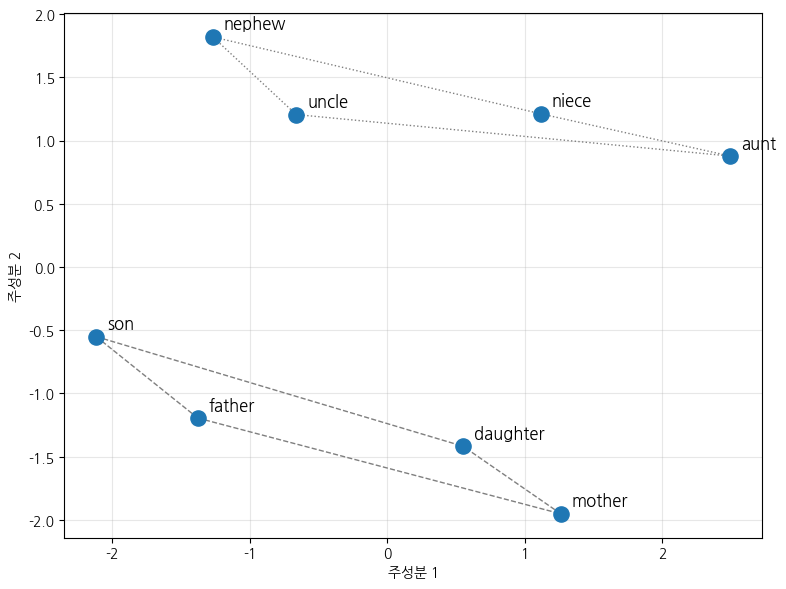

In [8]:
# 그림 7-6(계속) - 산포도 시각화 + 관계 단어 사이 연결선 표시
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# 단어 점 표시
ax.scatter(
    projection[:, 0], projection[:, 1], s=120, c='tab:blue', zorder=3,
)
# 단어 라벨
for w, (x, y) in zip(family_words, projection):
    ax.annotate(
        w, (x, y),
        textcoords='offset points', xytext=(8, 6),
        fontsize=12, zorder=4,
    )

# 직계 가족 사각형 (father-mother-son-daughter)
direct = [
    ('father', 'mother'),    # 부모 사이 (성별 관계)
    ('son', 'daughter'),     # 자식 사이 (성별 관계)
    ('father', 'son'),       # 직계 남자 (부모-자식)
    ('mother', 'daughter'),  # 직계 여자 (부모-자식)
]
for a, b in direct:
    ia, ib = family_words.index(a), family_words.index(b)
    ax.plot(
        [projection[ia, 0], projection[ib, 0]],
        [projection[ia, 1], projection[ib, 1]],
        color='tab:gray', linestyle='--', linewidth=1, zorder=2,
    )

# 삼촌 가족 사각형 (uncle-aunt-nephew-niece)
uncle = [
    ('uncle', 'aunt'),
    ('nephew', 'niece'),
    ('uncle', 'nephew'),
    ('aunt', 'niece'),
]
for a, b in uncle:
    ia, ib = family_words.index(a), family_words.index(b)
    ax.plot(
        [projection[ia, 0], projection[ib, 0]],
        [projection[ia, 1], projection[ib, 1]],
        color='tab:gray', linestyle=':', linewidth=1, zorder=2,
    )

#ax.set_title('가족 관계 단어들의 GloVe 임베딩 PCA 시각화')
ax.set_xlabel('주성분 1')
ax.set_ylabel('주성분 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
viz._finalize(fig)
plt.show()

본문 [그림 7-6] 처럼 직계 가족과 삼촌 가족이 두 군집으로 모이고, 성별·세대 관계가 평행하게 나타나는 경향을 볼 수 있다. 단 PCA 는 분산이 큰 두 방향에 투영하는 선형 기법이므로 본문 그림과 정확히 같은 좌표로 일치하지는 않는다. 비선형 기법(t-SNE, UMAP) 을 쓰면 군집 구조가 더 또렷해진다 (7장 학습 노트의 참고 자료 참조).

## 정리

- GloVe 6B 100d 는 40 만 토큰을 차원 100 의 벡터로 표현한 사전 학습된 임베딩이다.
- 토큰의 고유 번호를 알면 임베딩 행렬에서 인덱싱만으로 임베딩 벡터를 구할 수 있다 — 행렬곱이 필요 없다.
- 임베딩 벡터 사이의 거리와 방향에 단어의 의미·관계가 담긴다. 가족 관계 단어를 PCA 로 2 차원에 투영하면 직계와 삼촌 가족이 두 군집으로 분리되고, 성별·세대 관계가 평행 벡터로 보존되는 경향을 시각적으로 확인할 수 있다.